In [42]:
# import functions and other modules
import functions
import importlib
importlib.reload(functions)
import os
import pandas as pd
import warnings
import seaborn as sns
warnings.simplefilter(action='ignore', category=UserWarning)

# Global variables for files
INPUT = 'input/'
OUTPUT = 'output/'
BIN = 'bin/'

# Phylo

This notebook is used to analyse SNP files and perform phylogenetic analysis generating several output files

The analysis will NOT perform Mtb lineage assignment and should be run with the lineage notebook that is much faster

1. Set global parameters for the run that will be used throughout the script
2. Run the setup function to setup the input and output
2. Generate output

In [43]:
# Parameters for snp calling (quality, forward/reverse balance, frequency, coverage)
FREQ = 90
COV = 10
QUAL = 20
FRB = 0

In [44]:
# Setup input
functions.setupInput(INPUT)
snp_files = os.listdir(INPUT+'snp/')
cov_files = os.listdir(INPUT+'cov/')
stat_files = os.listdir(INPUT+'stat/')

# Setup output. Note: it will clear everything in the resisto output
functions.setupOutput(OUTPUT,'phylo')

# Parse databases for phylogenetics
DB_DR,DB_REP_NE,DB_LIN = functions.setupPhylo(BIN)

✅ Input files successfully renamed and all files valid CSV files

✅ Phylo output directories created

✅ Databases successfully loaded



In [45]:
# perform phylogenetics
params = [QUAL,FRB,FREQ,COV,INPUT,OUTPUT,BIN]
phylo_list = [DB_DR,DB_REP_NE,DB_LIN]

fasta = functions.mainPhylo(snp_files,params,phylo_list)

✅ Multiple sequence alignment completed!

✅ Phylogenetic tree built!



===========

The next part performs the snp difference analysis and visualisation

There are several parameters that can be set for the viz and some are mentioned here. Please check online for more viz parameters

In [47]:
# perform snp difference analysis and write to file
snp_dif = functions.snpDif(fasta)
snp_dif.to_csv(OUTPUT+'phylo/snpdif.csv')
clusters = functions.snpDifClusters(snp_dif,OUTPUT,threshold=12)

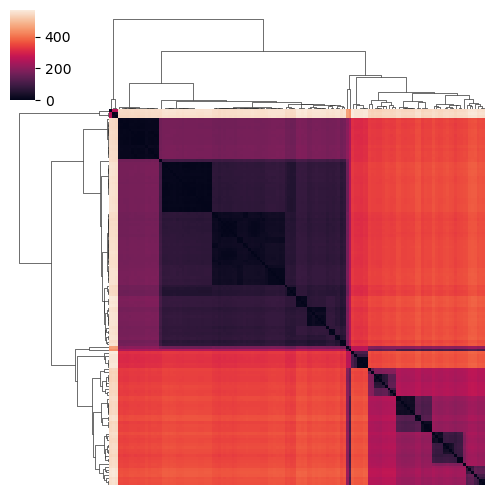

In [48]:
# visualisation
# figsize: size of figure
# yticklabels / xticklabels: if set to True it will show all labels if set to False it will show none
# cmap: sets the color scheme. Commonly used is viridis, mako or vlag. If left out the default is used

fig = sns.clustermap(data = snp_dif,
                     figsize = (5,5),
                     yticklabels = False,
                     xticklabels = False)
                     #cmap = 'mako')
fig.savefig(OUTPUT+'phylo/snpdif.png')